# DPO result analysis — before vs. after alignment

Reads `align/dpo_out/history.json` (written by `train_dpo.py --heldout-eval`) and analyses
what the offline DPO run did to ESM-C. Three questions:

1. **Did it learn the preference?** — val loss / reward accuracy / margin on held-out *natural* domains.
2. **Did it generalize?** — de novo ΔG-ranking Spearman on the leakage-free **test** set (148 de novo folds).
3. **At what cost?** — `kl_drift`: how far the policy moved off the reference manifold (reward-hacking watch).

> `step 0` is the untrained policy, which *equals* the reference — so it doubles as the **before** baseline.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BETA = 0.1  # must match the --beta used in training (needed to decompose the margin)

hist = json.load(open(Path('../align/dpo_out') / 'history.json'))
h = pd.DataFrame(hist)
print(f'{len(h)} eval points, steps {h.step.min()}..{h.step.max()}')
h.tail(3)

20 eval points, steps 0..3714


,val_loss,reward_acc,reward_margin,kl_drift,denovo_spearman_policy,denovo_spearman_base,denovo_spearman_delta_vs_dG,denovo_n,step
17,0.196434,0.947408,11.226657,-146.117889,0.519509,-0.053209,0.538492,3000,3400
18,0.205025,0.940436,10.490123,-208.624337,0.501927,-0.053209,0.519046,3000,3600
19,0.207381,0.946347,11.625700,-144.838575,0.511880,-0.053209,0.533311,3000,3714


## Before vs. after

In [2]:
before, after = h.iloc[0], h.iloc[-1]
cmp = pd.DataFrame({
    'before (step 0 = base)': before,
    f'after (step {int(after.step)})': after,
}).loc[['val_loss','reward_acc','reward_margin','kl_drift',
        'denovo_spearman_base','denovo_spearman_policy']]
cmp['\u0394'] = cmp.iloc[:,1] - cmp.iloc[:,0]
print(cmp.round(3).to_string())
print('\nReading it:')
print(f"  val_loss   {before.val_loss:.3f} -> {after.val_loss:.3f}   (baseline = ln2 = 0.693)")
print(f"  reward_acc {before.reward_acc:.3f} -> {after.reward_acc:.3f}   (fraction of held-out natural pairs ordered correctly)")
print(f"  de novo Spearman {before.denovo_spearman_base:+.3f} -> {after.denovo_spearman_policy:+.3f}   (TEST: pseudo-LL vs true \u0394G on unseen folds)")

                        before (step 0 = base)  after (step 3714)        Δ
val_loss                                 0.693              0.207   -0.486
reward_acc                               0.000              0.946    0.946
reward_margin                            0.000             11.626   11.626
kl_drift                                 0.000           -144.839 -144.839
denovo_spearman_base                    -0.053             -0.053    0.000
denovo_spearman_policy                  -0.053              0.512    0.565

Reading it:
  val_loss   0.693 -> 0.207   (baseline = ln2 = 0.693)
  reward_acc 0.000 -> 0.946   (fraction of held-out natural pairs ordered correctly)
  de novo Spearman -0.053 -> +0.512   (TEST: pseudo-LL vs true ΔG on unseen folds)


## Training curves (validation split = held-out natural domains)

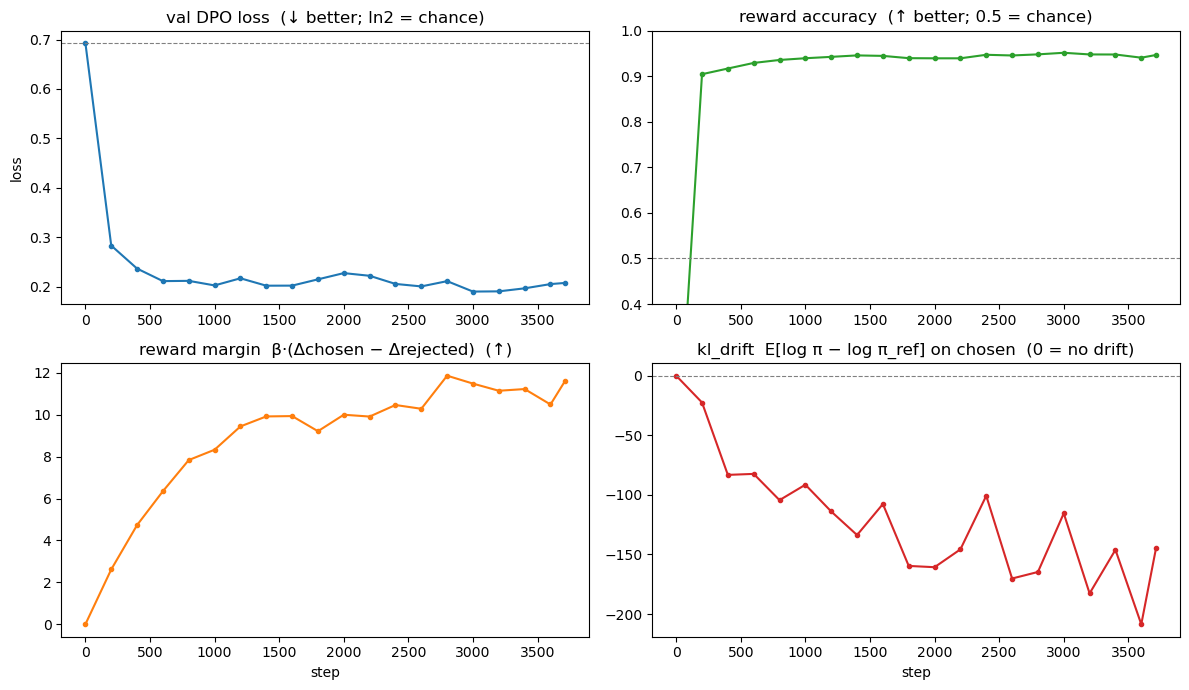

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
s = h.step
ax[0,0].plot(s, h.val_loss, '-o', ms=3); ax[0,0].axhline(np.log(2), ls='--', c='grey', lw=.8)
ax[0,0].set_title('val DPO loss  (\u2193 better; ln2 = chance)'); ax[0,0].set_ylabel('loss')
ax[0,1].plot(s, h.reward_acc, '-o', ms=3, c='C2'); ax[0,1].axhline(0.5, ls='--', c='grey', lw=.8)
ax[0,1].set_ylim(0.4, 1.0); ax[0,1].set_title('reward accuracy  (\u2191 better; 0.5 = chance)')
ax[1,0].plot(s, h.reward_margin, '-o', ms=3, c='C1')
ax[1,0].set_title('reward margin  \u03b2\u00b7(\u0394chosen \u2212 \u0394rejected)  (\u2191)'); ax[1,0].set_xlabel('step')
ax[1,1].plot(s, h.kl_drift, '-o', ms=3, c='C3'); ax[1,1].axhline(0, ls='--', c='grey', lw=.8)
ax[1,1].set_title('kl_drift  E[log \u03c0 \u2212 log \u03c0_ref] on chosen  (0 = no drift)'); ax[1,1].set_xlabel('step')
plt.tight_layout(); plt.show()

## The test set: de novo ΔG ranking, and the reward-hacking watch

Left: does the policy's pseudo-LL rank **true ΔG** better than base, on folds it never trained on?
Right: **likelihood displacement** — decompose the margin to see whether DPO *raised* the
chosen likelihood or just *crushed* the rejected one. If both `\u0394chosen` and `\u0394rejected`
plunge, the model is drifting off-manifold (margin looks great for the wrong reason).

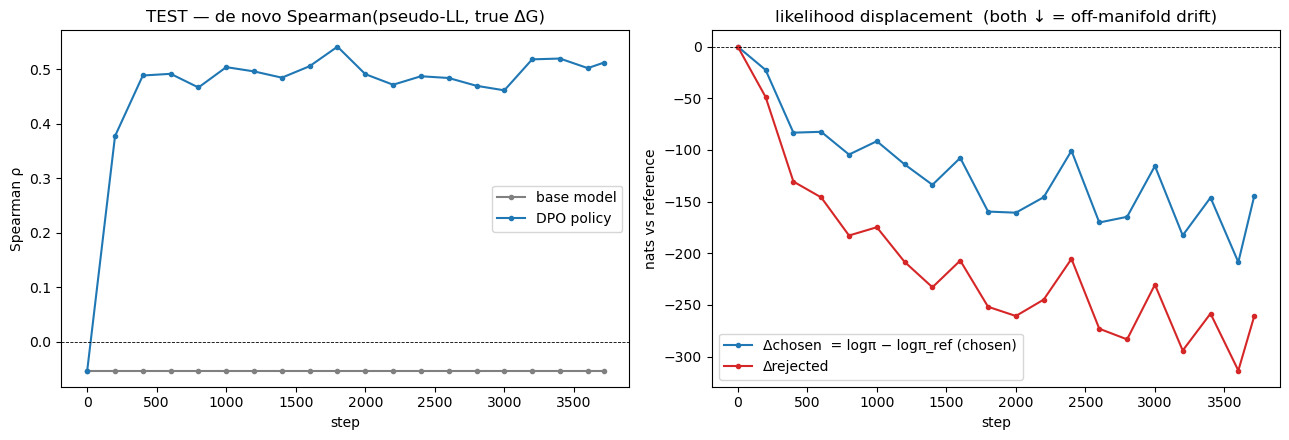

final Δchosen   = -144.8 nats
final Δrejected = -261.1 nats
DPO kept the *gap* (reward) while pushing both absolute likelihoods far below the base model.


In [4]:
# decompose:  margin = BETA*(d_chosen - d_rejected),  kl_drift = d_chosen
d_chosen = h.kl_drift
d_rejected = h.kl_drift - h.reward_margin / BETA

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(s, h.denovo_spearman_base, '-o', ms=3, c='grey', label='base model')
ax[0].plot(s, h.denovo_spearman_policy, '-o', ms=3, c='C0', label='DPO policy')
ax[0].axhline(0, ls='--', c='k', lw=.6)
ax[0].set_title('TEST \u2014 de novo Spearman(pseudo-LL, true \u0394G)')
ax[0].set_xlabel('step'); ax[0].set_ylabel('Spearman \u03c1'); ax[0].legend()

ax[1].plot(s, d_chosen, '-o', ms=3, c='C0', label='\u0394chosen  = log\u03c0 \u2212 log\u03c0_ref (chosen)')
ax[1].plot(s, d_rejected, '-o', ms=3, c='C3', label='\u0394rejected')
ax[1].axhline(0, ls='--', c='k', lw=.6)
ax[1].set_title('likelihood displacement  (both \u2193 = off-manifold drift)')
ax[1].set_xlabel('step'); ax[1].set_ylabel('nats vs reference'); ax[1].legend()
plt.tight_layout(); plt.show()

print(f'final \u0394chosen   = {d_chosen.iloc[-1]:+.1f} nats')
print(f'final \u0394rejected = {d_rejected.iloc[-1]:+.1f} nats')
print('DPO kept the *gap* (reward) while pushing both absolute likelihoods far below the base model.')

## Optional: per-sequence pseudo-LL vs ΔG scatter (reloads ESM-C + adapters)

The history only has the *summary* Spearman. This reloads the base model and the saved LoRA
adapters and scores a de novo subsample directly, so we can see the scatter shift. Slow-ish
(~1\u20132 min on GPU); set `RUN=False` to skip.

ESMC: transformer_engine is not installed; falling back to pure-PyTorch LayerNorm+Linear / LayerNorm+MLP. Outputs will differ numerically — measured on the unnormalized residual stream (before the final LayerNorm), ~O(10) max-diff in fp32 and ~O(100) in bf16; after the final LayerNorm these shrink to a few ULP and perplexity stays within rounding noise. Install with `pip install transformer-engine[pytorch]` to enable fused fp32-reduction LayerNorm.
ESMC: neither xformers nor flash-attn is installed; falling back to PyTorch ``F.scaled_dot_product_attention``. The attention reduction order in bf16 differs from a fused kernel by ~1 bf16 ULP per attention block; compounded across the 80-block stack this reaches ~O(100) max-diff on the unnormalized residual stream. Install xformers (preferred) with `pip install xformers` for a fused attention kernel.
ESMC: flash-attn rotary kernel not installed; falling back to pure-PyTorch RoPE. For faster GPU inference run `pip install flash-attn`.


🚨 No checkpoint found for ESMCForSequenceClassification.forward. Please add a `checkpoint` arg to `auto_docstring` or add one in ESMCConfig's docstring
🚨 No checkpoint found for ESMCForTokenClassification.forward. Please add a `checkpoint` arg to `auto_docstring` or add one in ESMCConfig's docstring


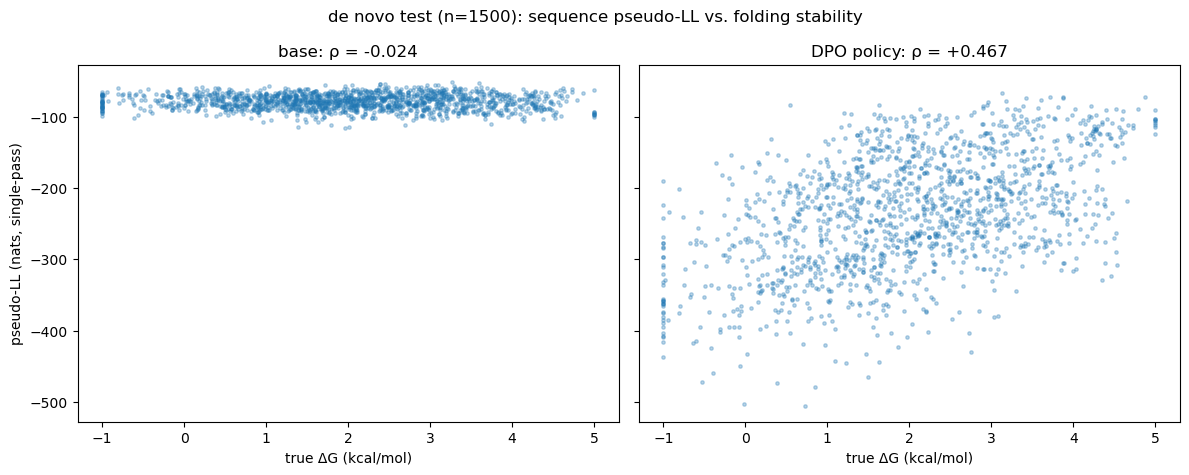

In [5]:
RUN = True
N = 1500

if RUN:
    import sys, torch
    from scipy.stats import spearmanr
    sys.path.insert(0, '../align')  # import the scorer from train_dpo.py
    from train_dpo import seq_logp
    from transformers import AutoModelForMaskedLM, AutoTokenizer
    from peft import PeftModel

    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    MID = 'biohub/ESMC-300M'
    tok = AutoTokenizer.from_pretrained(MID)
    special = torch.tensor([i for i in (tok.cls_token_id, tok.eos_token_id, tok.pad_token_id)
                            if i is not None], device=dev)
    base = AutoModelForMaskedLM.from_pretrained(MID, dtype='auto')
    model = PeftModel.from_pretrained(base, '../align/dpo_out/best').to(dev).eval()

    df = pd.read_csv(Path('..') / 'data' / 'prepared' / 'reward_table.csv',
                     usecols=['origin','aa_seq','dG'])
    df = df[(df.origin=='de_novo') & df.dG.notna()].sample(N, random_state=0)
    seqs, dG = df.aa_seq.tolist(), df.dG.to_numpy()

    @torch.inference_mode()
    def score(policy):
        ctx = (lambda: __import__('contextlib').nullcontext())() if policy else model.disable_adapter()
        out = []
        with ctx:
            for i in range(0, len(seqs), 32):
                e = tok(seqs[i:i+32], return_tensors='pt', padding=True).to(dev)
                out.append(seq_logp(model, e['input_ids'], e['attention_mask'], special, False).cpu().numpy())
        return np.concatenate(out)

    ll_base, ll_pol = score(False), score(True)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
    for a, ll, name in [(ax[0], ll_base, 'base'), (ax[1], ll_pol, 'DPO policy')]:
        a.scatter(dG, ll, s=6, alpha=.3)
        a.set_title(f'{name}: \u03c1 = {spearmanr(ll, dG).statistic:+.3f}')
        a.set_xlabel('true \u0394G (kcal/mol)')
    ax[0].set_ylabel('pseudo-LL (nats, single-pass)')
    plt.suptitle(f'de novo test (n={N}): sequence pseudo-LL vs. folding stability')
    plt.tight_layout(); plt.show()

## Interpretation

- **Learned the preference (val).** `reward_acc` climbs 0.5 \u2192 ~0.95 and `val_loss` drops well below
  ln2 \u2014 the policy orders unseen *natural* preference pairs almost perfectly.
- **Generalized to the test set.** de novo Spearman jumps from ~0 (base) to ~0.5 \u2014 on leakage-free
  folds the aligned policy's likelihood now tracks true \u0394G about as well as the supervised ridge probe.
  This is the positive headline: alignment on natural preferences **transferred** to de novo stability.
- **But it drifted hard.** `kl_drift` \u2192 \u2212145 nats and the displacement plot shows *both* \u0394chosen and
  \u0394rejected collapsing \u2014 DPO kept the reward *gap* while driving all absolute likelihoods far below
  the base model (classic likelihood displacement). \u03b2=0.1 was too permissive.

**Is the 0.5 real or hacked?** The stability ranking improved, which argues against pure hacking on the
\u0394G axis \u2014 but the huge drift means naturalness likely fell. Deciding this needs the held-out
naturalness (perplexity) + foldability (ESMFold pLDDT) oracles, and a **\u03b2 sweep**: if 0.5 survives at
smaller drift it's signal; if it collapses as KL is constrained it was riding the off-manifold drift.

_(Magnitudes here use single-pass pseudo-LL, which self-leaks; re-run the de novo eval with
`--mask-scoring` to confirm the ranking holds under leak-free scoring.)_